Displaying SIFT Features for Image 1...


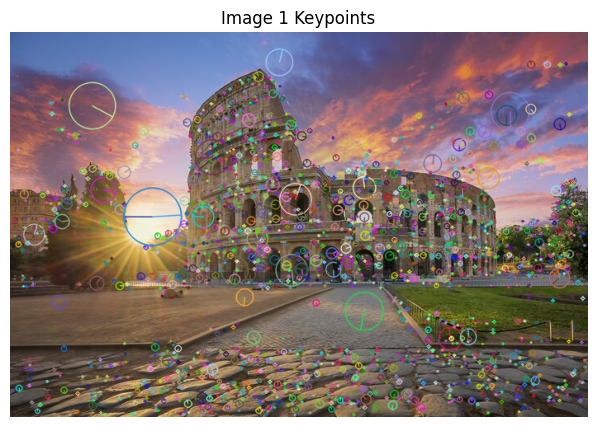

Displaying Matched Features...


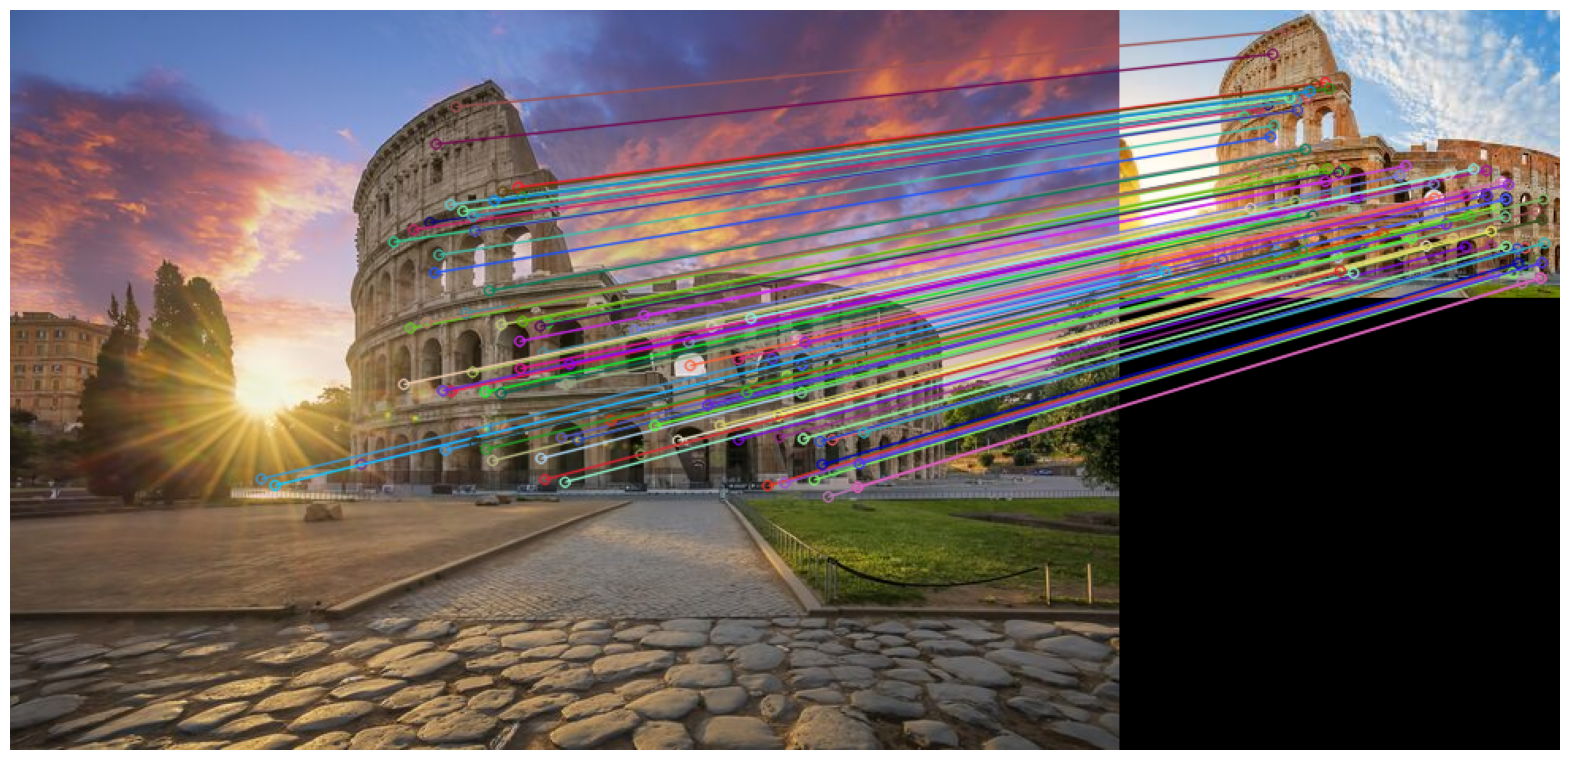

In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

sift = cv2.SIFT_create()

image_path1 = "italy-1.jpg"
image_path2 = "italy.jpg"

Image1 = cv2.imread(image_path1)
Image2 = cv2.imread(image_path2)

if Image1 is None or Image2 is None:
    raise FileNotFoundError(
        "Could not load one of the images. Please check your file paths!"
    )

Image1_gray = cv2.cvtColor(Image1, cv2.COLOR_BGR2GRAY)
Image2_gray = cv2.cvtColor(Image2, cv2.COLOR_BGR2GRAY)

Image1_key_points, Image1_descriptors = sift.detectAndCompute(
    Image1_gray, None
)
Image2_key_points, Image2_descriptors = sift.detectAndCompute(
    Image2_gray, None
)

print("Displaying SIFT Features for Image 1...")
sift_image1 = cv2.drawKeypoints(
    Image1,
    Image1_key_points,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
)
plt.figure(figsize=(10, 5))
plt.imshow(cv2.cvtColor(sift_image1, cv2.COLOR_BGR2RGB))
plt.title("Image 1 Keypoints")
plt.axis("off")
plt.show()

FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)

flann = cv2.FlannBasedMatcher(index_params, search_params)
matches = flann.knnMatch(Image1_descriptors, Image2_descriptors, k=2)

good_matches = []
for m, n in matches:
    if m.distance < 0.7 * n.distance:
        good_matches.append(m)

if len(good_matches) > 4:
    src_pts = np.float32(
        [Image1_key_points[m.queryIdx].pt for m in good_matches]
    ).reshape(-1, 1, 2)
    dst_pts = np.float32(
        [Image2_key_points[m.trainIdx].pt for m in good_matches]
    ).reshape(-1, 1, 2)

    M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
    matchesMask = mask.ravel().tolist()

    inlier_matches = [
        good_matches[i] for i in range(len(good_matches)) if matchesMask[i]
    ]
else:
    inlier_matches = good_matches

inlier_matches = sorted(inlier_matches, key=lambda match: match.distance)

matched_img = cv2.drawMatches(
    Image1,
    Image1_key_points,
    Image2,
    Image2_key_points,
    inlier_matches[:100],
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
)

print("Displaying Matched Features...")
plt.figure(figsize=(20, 10))
plt.imshow(cv2.cvtColor(matched_img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()